In [26]:
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import jit


### Variable

In [27]:
dim = 100
I = 1 # A
hx = 1 # pas spatial
hy = 1 # pas spatial

x = np.linspace(0, dim, dim)
y = np.linspace(0, dim, dim)

xx, yy = np.meshgrid(x, y)

# demi_dist = 5

A = (98, 46)
B = (98, 54)
# M = (48, 98)
# N = (51, 98)

M = (98, 48)
N = (98, 52)


### On met une matrice de conductivité

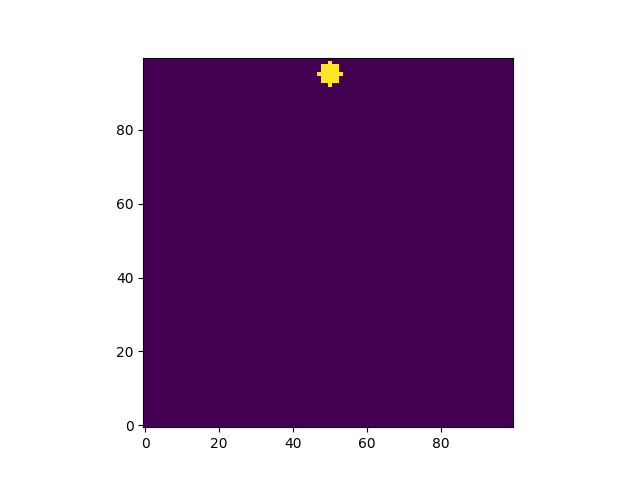

In [28]:
sigma_init = np.ones((dim, dim))# np.random.uniform(low=1, high=10, size=(dim, dim))

xx, yy = np.meshgrid(np.arange(dim), np.arange(dim), indexing='ij')

sigma_init[(xx-95)**2 + (yy-50)**2 <= 3**2] = 500


# sigma_init[: 81, dim//2 - 50: dim//2 + 50] = 100
pot_init = np.zeros((dim, dim))

courant_init = np.zeros((dim, dim))
courant_init[A[0]:dim, A[1]] = I
courant_init[B[0]:dim, B[1]] = -I

plt.figure()
plt.imshow(sigma_init, origin='lower')

# plt.imshow(courant_init, origin='lower')



### Calcul du potentiel

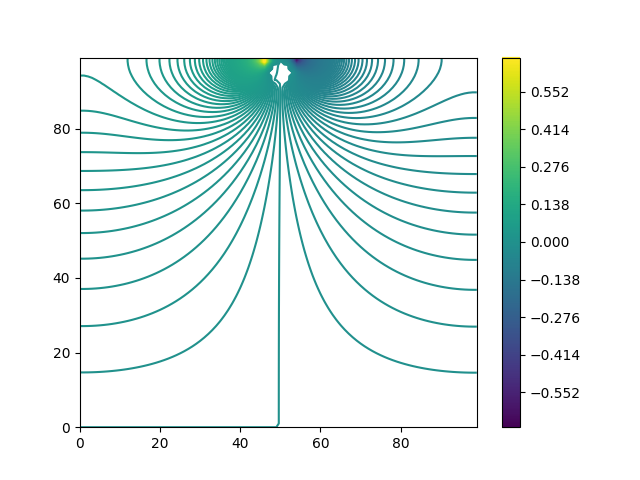

In [ ]:
t numpy as np
import matplotlib.pyplot as plt
import numba

%matplotlib widget



niter = 1000000
tol = 1e-8
error=1e10
it=0

@numba.jit
def compute_pot(V, V_k, Sigma, I):
    l = len(V[0])
    h = 1
    for i in range(1, l-1):
        for j in range(1, l-1):
            
            sigma_ifhs = (2*Sigma[j, i]*Sigma[j, i+1])/(Sigma[j, i] + Sigma[j, i+1])
            sigma_ibhs = (2*Sigma[j, i]*Sigma[j, i-1])/(Sigma[j, i] + Sigma[j, i-1])
            sigma_jfhs = (2*Sigma[j, i]*Sigma[j+1, i])/(Sigma[j, i] + Sigma[j+1, i])
            sigma_jbhs = (2*Sigma[j, i]*Sigma[j-1, i])/(Sigma[j, i] + Sigma[j-1, i])

            deno = sigma_ifhs + sigma_ibhs + sigma_jfhs + sigma_jbhs

            nom = (I[j, i]*(h**2)) + sigma_ifhs*V_k[j, i+1] + sigma_ibhs*V_k[j, i-1] + sigma_jfhs*V_k[j+1, i] + sigma_jbhs*V_k[j-1, i]

            V[j, i] = nom/deno

    return V

@numba.jit
def find_pot(V, Sigma, I, DIM, error=1e10, tol=1e-8, niter=1000000):
    it=0
    while error > tol and it < niter:
        V_k = V.copy()

        V[0, :] = 0 # haut
        V[-1, :] = V[-2, :] # bas
        V[:, 0] = V[:, 1] # gauche
        V[:, DIM-1] = V[:, DIM-2] # gauche
        #  = 0 # droite

        V = compute_pot(V, V_k, Sigma, I)

        diff = V - V_k
        error = np.sqrt(np.sum(diff**2))#np.linalg.norm(diff)

        it += 1

    return V

Voltage = find_pot(pot_init, sigma_init, courant_init, DIM=dim)

# print(f"Nombre d'itérations: {it}")
# print(f"Erreur: {error}")


plt.figure()
# plt.imshow(Voltage, origin='lower')
plt.contour(Voltage, levels=500)
# plt.imshow(pot)
plt.colorbar()
                

### Mesure de la différence de potentiel

In [30]:
# def coord_schlumb(A_i, B_i, max_dist):
#     A_to_move = A_i[1]
#     B_to_move = B_i[1]
#     A_list = []
#     B_list = []
#     for i in range(2, max_dist, 2):
#         A = A_to_move - i
#         B = B_to_move + i
#         A_list.append(A)
#         B_list.append(B)

#     return list(zip(A_list, B_list))

# c = coord_schlumb(A, B, 45)

# def pot_for_schlumb(V, M, N):

#     dV = V[M[0], M[1]] - V[N[0], N[1]]
#     return dV


# def app_res(coord_ab, dimension, cond, I):
#     V_i = np.zeros((dimension, dimension))

#     rho_app = []
#     AB_2 = []

#     for i in coord_ab:
#         a, b = i
#         AB_2.append(abs(b-a)/2)
#         I0 = np.zeros((dimension, dimension))
#         V_i = np.zeros((dimension, dimension))
#         I0[98:, a]=I
#         I0[98:, b]=-I

#         V = find_pot(V_i, cond, I0, DIM=dimension)

#         V_MN = pot_for_schlumb(V, M, N)

#         # print(M, N)
#         # print(a, b)

#         K = np.pi * (((abs(b-a)/2)**2 - (abs(M[1]-N[1])/2)**2) / abs(M[1]-N[1]))#(2 * np.pi) / ((1/abs(a-M[1])) - (1/abs(b-M[1])) - (1/abs(a-N[1])) + (1/abs(b-N[1])))

#         rho_ap = K*V_MN/I
#         rho_app.append(rho_ap)

#     return np.array(rho_app), np.array(AB_2)

# rho_a, ab2 = app_res(c, dim, sigma_init, I)






In [31]:
import numpy as np
from joblib import Parallel, delayed

def coord_schlumb(A_i, B_i, max_dist):
    A_to_move = A_i[1]
    B_to_move = B_i[1]
    A_list = []
    B_list = []
    for i in range(2, max_dist, 2):
        A = A_to_move - i
        B = B_to_move + i
        A_list.append(A)
        B_list.append(B)

    return list(zip(A_list, B_list))

c = coord_schlumb(A, B, 45)

def compute_one_ab(a, b, dimension, cond, I, M, N):
    # Injection courant
    I0 = np.zeros((dimension, dimension))
    I0[98:, a] = I
    I0[98:, b] = -I

    # Solveur
    V = find_pot(np.zeros((dimension, dimension)), cond, I0, DIM=dimension)

    # Différence de potentiel
    dV = V[M[0], M[1]] - V[N[0], N[1]]

    # Géométrie
    AB = abs(b - a)
    AB_2 = AB / 2

    MN_dist = abs(M[1] - N[1])
    MN_term = (MN_dist / 2)**2

    K = np.pi * ((AB_2**2 - MN_term) / MN_dist)

    rho = K * dV / I

    return rho, AB_2


def app_res_parallel(coord_ab, dimension, cond, I, M, N, n_jobs=-1):

    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_one_ab)(a, b, dimension, cond, I, M, N)
        for (a, b) in coord_ab
    )

    rho_app, AB_2 = zip(*results)

    return np.array(rho_app), np.array(AB_2)

In [32]:
rho_a, ab2 = app_res_parallel(c, dim, sigma_init, I, M, N)

### Résistivité apparente du sol

Text(0.5, 0, 'Demi-distance entre les électrodes [m]')

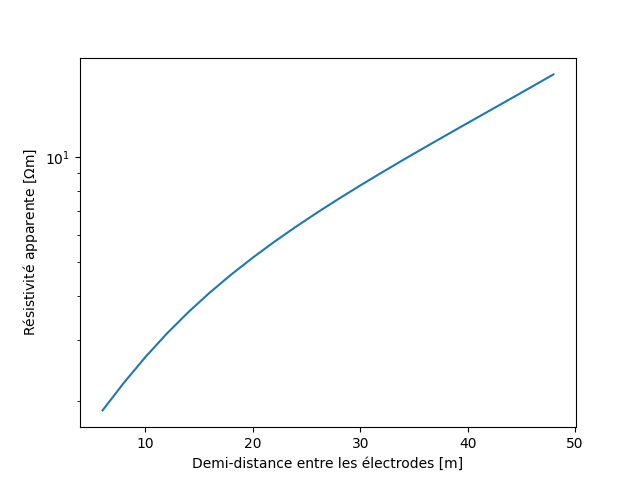

In [33]:


plt.figure()
# plt.contourf(xx, yy, V_[0], levels=200)
plt.plot(ab2, rho_a)
plt.yscale('log')
plt.ylabel(r"Résistivité apparente [$\Omega$m]")
plt.xlabel("Demi-distance entre les électrodes [m]")

# plt.show()

### On trouve la pseudo-section

La pseudo-section est un "mapping" de la résistivité apparent du sous-sol.

In [34]:
# def pseudo_section(dimension, cond, I):
#     pseudo = np.zeros((dimension, dimension))

#     A_i = [dimension-2, 2]
#     M_i = [dimension-2, 4]
#     N_i = [dimension-2, 6]
#     B_i = [dimension-2, 8]

#     A_i_modif = A_i.copy()
#     B_i_modif = B_i.copy()
#     M_i_modif = M_i.copy()
#     N_i_modif = N_i.copy()

#     ligne = dimension-2
#     while B_i_modif[1] - A_i_modif[1] <= dimension-2:

#         a, b, m, n = A_i_modif[1], B_i_modif[1], M_i_modif[1], N_i_modif[1]

#         print(B_i_modif[1] - A_i_modif[1])
#         print(a, m, n, b)

#         I0 = np.zeros((dimension, dimension))
#         V_i = np.zeros((dimension, dimension))
        
#         I0[A_i_modif[0]:, A_i_modif[1]]=I
#         I0[B_i_modif[0]:, B_i_modif[1]]=-I

#         V = find_pot(V_i, cond, I0, DIM=dimension)

#         V_MN = pot_for_schlumb(V, M_i_modif, N_i_modif)

#         K = np.pi * (((abs(b-a)/2)**2 - (abs(m-n)/2)**2) / abs(m-n))
        
#         centre = (m + n)//2
#         pseudo[ligne, centre] = K*V_MN/I
#         A_i_modif[1] += 10
#         B_i_modif[1] += 10
#         M_i_modif[1] += 10
#         N_i_modif[1] += 10

#         if B_i_modif[1] >= dimension-2:
#             ligne -= 1
#             A_i_modif[1] = 2
#             B_i_modif[1] = B_i[1] + 8
#             M_i_modif[1] = M_i[1] + 4
#             N_i_modif[1] = N_i[1] + 4
#             A_i[1] += 4
#             B_i[1] += 8
#             M_i[1] += 4
#             N_i[1] += 4
#             # M_i_modif[1] += 1
#             # N_i_modif[1] += 1

#     return pseudo

In [35]:
import numpy as np
from joblib import Parallel, delayed


def compute_measure(a, b, m, n, dimension, cond, I):

    # courant
    I0 = np.zeros((dimension, dimension))
    I0[dimension-2:, a] = I
    I0[dimension-2:, b] = -I

    # solveur
    V = find_pot(np.zeros((dimension, dimension)), cond, I0, DIM=dimension)

    # potentiel
    dV = V[dimension-2, m] - V[dimension-2, n]

    # géométrie
    AB = abs(b - a)
    MN = abs(m - n)

    K = np.pi * (((AB/2)**2 - (MN/2)**2) / MN)

    rho = K * dV / I

    # coordonnées pseudo-section
    x = (m + n) / 2
    z = AB / 2

    return x, z, rho


def pseudo_section_parallel(dimension, cond, I, n_jobs=-1):

    tasks = []

    A0, M0, N0, B0 = 2, 4, 6, 8

    while B0 <= dimension - 2:

        for shift in range(0, dimension, 10):

            a = A0 + shift
            m = M0 + shift
            n = N0 + shift
            b = B0 + shift

            if b >= dimension:
                break

            tasks.append((a, b, m, n))

        A0 += 4
        M0 += 4
        N0 += 4
        B0 += 8

    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(compute_measure)(a, b, m, n, dimension, cond, I)
        for (a, b, m, n) in tasks
    )

    xs, zs, rhos = zip(*results)

    return np.array(xs), np.array(zs), np.array(rhos)

In [36]:
pseudo_section_array = pseudo_section_parallel(dim, sigma_init, I)
# plt.imshow(pseudo_section_array)

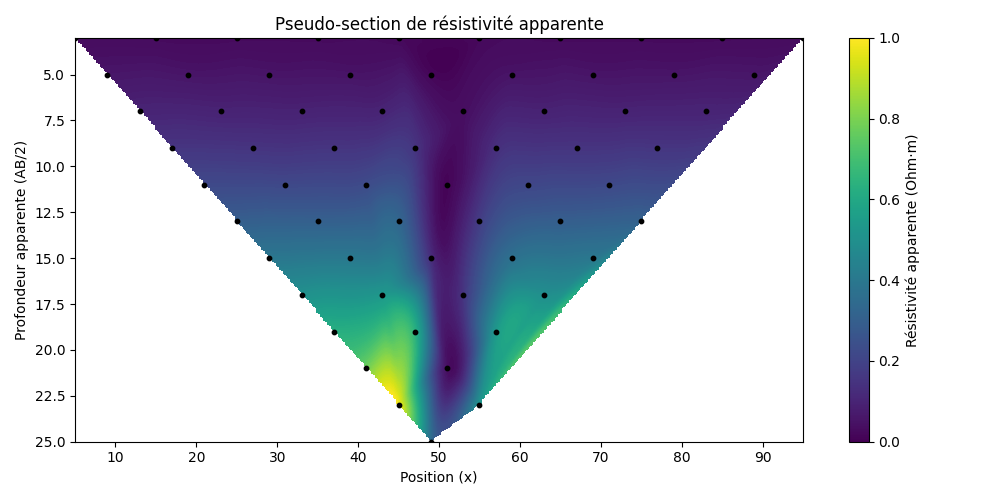

In [40]:
# plt.figure()
# plt.imshow(pseudo_section_array, origin='lower')
# plt.show()
x, z, rho_app = pseudo_section_array

from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# grille régulière
xi = np.linspace(x.min(), x.max(), 200)
zi = np.linspace(z.min(), z.max(), 200)

XI, ZI = np.meshgrid(xi, zi)

# interpolation
RHOI = griddata((x, z), rho_app, (XI, ZI), method='cubic')

plt.figure(figsize=(10, 5))

# contour rempli
plt.contourf(XI, ZI, RHOI, levels=200)
# plt.imshow(RHOI, origin='lower')

# points de mesure (optionnel mais pro)
plt.scatter(x, z, c='k', s=10)

plt.gca().invert_yaxis()  # profondeur vers le bas

plt.xlabel("Position (x)")
plt.ylabel("Profondeur apparente (AB/2)")

plt.title("Pseudo-section de résistivité apparente")

plt.colorbar(label="Résistivité apparente (Ohm·m)")

plt.tight_layout()
plt.show()